### Objetivos do Notebook

Notebook reponsável por extrair a tabela de origem ssi_dim_empresas do datamart de SSI  armazenadas no sistema S+ e salvar esses dados no formato Parquet no bucket bronze do MinIO.

### Data Owner
Rodrigo Souza - rodrigo.souza@sfiemt.ind.br

### Horário de execução do Notebook
Não executado



### Origens extraídas do S+
As seguintes tabelas serão extraídas do sistema S+:

- **ssi_dim_empresas**

### Local de destino no bucket bronze
Os datasets resultantes gerados pela extração do notebook serão armazenados no bucket bronze do MinIO no formato Parquet, seguindo a estrutura de diretórios e nomes de arquivos baseados na data de execução do notebook.

- **ssi_dim_empresas:** bronze/ssi/smais/ssi_dim_empresas/{data_execucao}/ssi_dim_empresas_{data_execucao}.parquet

### Linhagem de dados
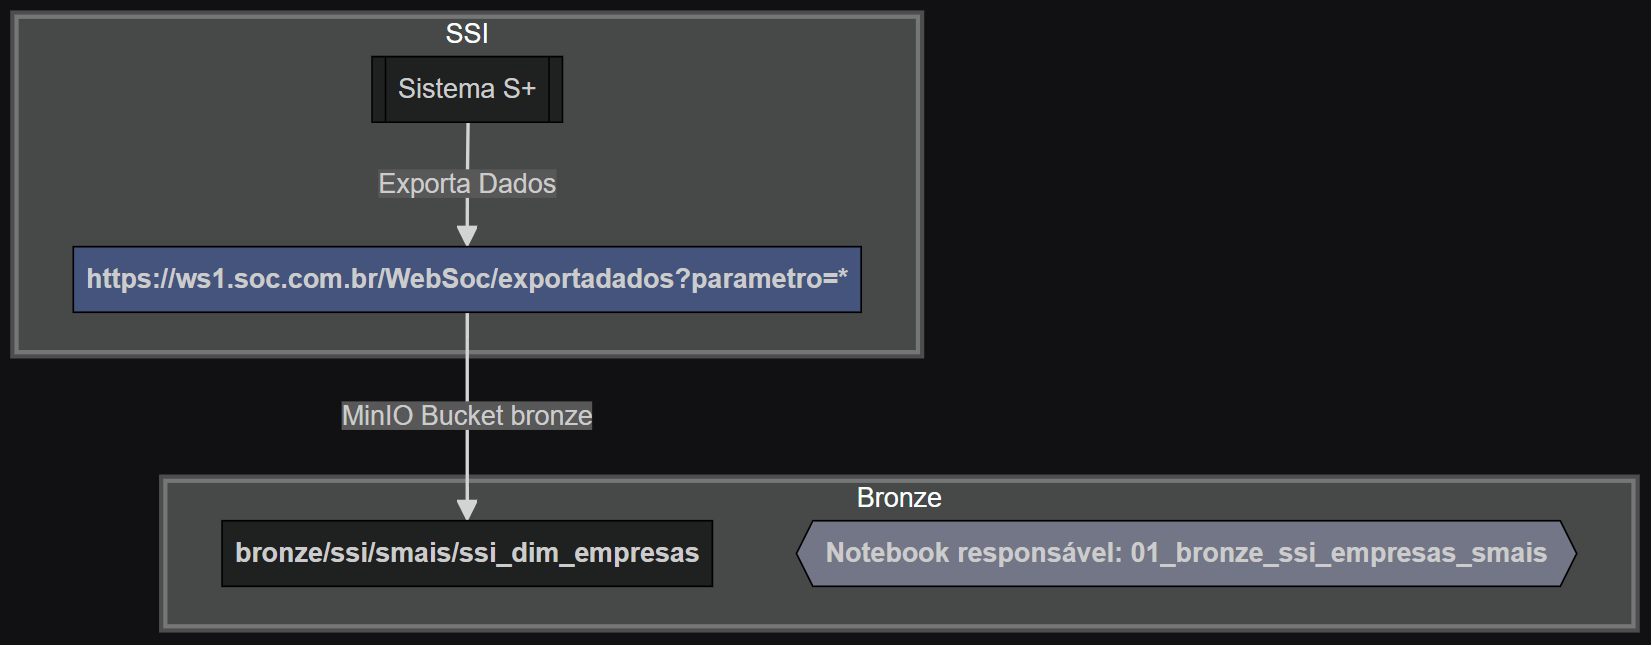

# Bibliotecas necessárias

In [1]:
import os
import warnings
from datetime import datetime
import pandas as pd
from util.SSIExportas import Exporta
from util.SSIUtils import insert_datalake
import json

warnings.filterwarnings("ignore")

# Declaração Variáveis

In [2]:
data_atual = datetime.now()
data_formatada = data_atual.strftime("%Y%m%d")

# Cria diretório temporário

In [6]:
if not os.path.exists('/home/jovyan/work/notebooks/01-bronze/ssi/util/tmp/'):
   os.mkdir('/home/jovyan/work/01-bronze/ssi/util/tmp')
else:
   print("O diretório 'util/tmp' já existe")

# Obtendo credenciais da API

In [13]:
# Converter a string JSON em uma lista de Python
#cadastro_empresas_credentials = os.getenv('CADASTRO_EMPRESAS_CREDENTIALS')
#exporta_credentials = json.loads(cadastro_empresas_credentials)


exporta_credentials = [
    {"unidade": 521267, "cod_exporta": 31933, "chave_exporta": "a1ad7eeca0e3db78bf79"},
    {"unidade": 521267, "cod_exporta": 191753, "chave_exporta": "a3ace4304c7cafc37a1b"},
    {"unidade": 521267, "cod_exporta": 184407, "chave_exporta": "31fdfe6930b041faed65"},
    {"unidade": 521267, "cod_exporta": 191754, "chave_exporta": "ddced2a9f4619ae21300"},
    {"unidade": 521267, "cod_exporta": 35792, "chave_exporta": "b1abaaf94e45f471a39d"},
    {"unidade": 521267, "cod_exporta": 191755, "chave_exporta": "fbe4920f8c8d7a239d31"},
    {"unidade": 521267, "cod_exporta": 34953, "chave_exporta": "b53fbc9e9bbe1dc301a0"},
    {"unidade": 521267, "cod_exporta": 31130, "chave_exporta": "7ca425849a2f67173fb6"},
    {"unidade": 521267, "cod_exporta": 191756, "chave_exporta": "76658908c398d86ae79"},
    {"unidade": 521267, "cod_exporta": 191757, "chave_exporta": "2912c111b5f03f3cf225"},
]

# Realizando buscas na API para cada empresa em cada unidade

In [14]:
frames = []
# Loop
for exporta in exporta_credentials:
    #Retorna unidade da lista exporta_configs
    unidade = exporta["unidade"]
    #Retorna cod_exporta da lista exporta_configs
    cod_exporta = exporta["cod_exporta"]
    #Retorna chave_exporta da lista exporta_configs
    chave_exporta = exporta["chave_exporta"]

    # Instancia função Exporta (passando unidade, codigo, chave)
    EXPORTA = Exporta(unidade=unidade, codigo=cod_exporta, chave=chave_exporta)

    # Chama função cadastro_empresas de Exporta (ExportaDados: Instância da classe ExportaDados com as configurações para exportação do cadastro de empresas.)
    UNIDADE = EXPORTA.cadastro_empresas()

    #Chama função get_df de ExportaDados, e cria a coluna UNIDADEVINCULADA passando a unidade da lista de exposta_configs
    df = UNIDADE.get_df({"UNIDADEVINCULADA": unidade, "dt_carga": data_atual})  
    if not df.empty:
        frames.append(df)  

In [15]:
df

,Metodo de acesso não permitido


# Tratamentos

In [6]:
# # Junção dos frames para geração de dataframe final
# df = pd.concat(frames)

In [7]:
# # Remoção de dados duplicados 
# df = df.drop_duplicates()

In [8]:
# mapping = {'0':'ATIVO', '1':'INATIVO'}
# df['ATIVO'] = df['ATIVO'].map(mapping)

In [9]:
# # Aplica uma função lambda a todas as colunas do DataFrame, exceto nas colunas a ignorar
# df = df.apply(lambda col: col.str.replace(r'\t', '') if col.name and col.dtype == 'object' else col)

In [10]:
# # Gravação no diretório temporário para apoio de outro datasets
# df.to_csv(os.path.join("/home/jovyan/work/notebooks/01-bronze/ssi/util/tmp", "empresas.csv"), index=False)

# Inserindo no Data Lake

In [11]:
# insert_datalake(df, 'ssi_dim_empresas')

Removendo arquivos do Bucket
Enviando ssi_dim_empresas para o Bucket bronze do minIO
